# Notebook 6 ? Final Test Evaluation

## Purpose

Perform the final unbiased evaluation of the selected late-delivery model.

Notebook 5 already froze:

- the feature contract;
- preprocessing;
- model family;
- model hyperparameters;
- classification threshold.

## Frozen model

Balanced logistic regression.

## Frozen decision threshold

`0.708020`

## Final training strategy

The selected model is retrained using the combined training and validation data.

The test split is then opened for the first and only final evaluation.

## Important rule

The test results must **not** be used to tune the model.

This preserves the test set as an honest estimate of performance on later unseen orders.


## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

SELECTED_MODEL_NAME = "logistic_balanced"
SELECTED_THRESHOLD = 0.708020

NOTEBOOK_5_VALIDATION_PR_AUC = 0.133260
NOTEBOOK_5_VALIDATION_ROC_AUC = 0.774280

print(f"scikit-learn version: {sklearn.__version__}")
print(f"Frozen model: {SELECTED_MODEL_NAME}")
print(f"Frozen threshold: {SELECTED_THRESHOLD:.6f}")
print("Imports completed successfully.")

scikit-learn version: 1.9.0
Frozen model: logistic_balanced
Frozen threshold: 0.708020
Imports completed successfully.


## 2. Load train, validation, and final test artifacts

This is the first notebook where the test split is intentionally loaded.

No model decisions will be changed after seeing the test results.


In [2]:
WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIR.parent if WORKING_DIR.name == "notebooks" else WORKING_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_PATH = PROCESSED_DIR / "train.parquet"
VALIDATION_PATH = PROCESSED_DIR / "validation.parquet"
TEST_PATH = PROCESSED_DIR / "test.parquet"

for path in [TRAIN_PATH, VALIDATION_PATH, TEST_PATH]:
    assert path.exists(), f"Missing artifact: {path}"

train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)

print(f"Training rows: {len(train):,}")
print(f"Validation rows: {len(validation):,}")

print("\n=== FINAL TEST OPEN ===")

test = pd.read_parquet(TEST_PATH)

print(f"Test rows: {len(test):,}")
print(f"Test columns: {test.shape[1]}")
print(f"Test late orders: {int(test['is_late'].sum()):,}")
print(f"Test late rate: {test['is_late'].mean():.4%}")
print("Test data opened: YES ? FINAL EVALUATION ONLY")

Training rows: 67,529
Validation rows: 14,470

=== FINAL TEST OPEN ===
Test rows: 14,471
Test columns: 67
Test late orders: 620
Test late rate: 4.2844%
Test data opened: YES ? FINAL EVALUATION ONLY


## 3. Reproduce the frozen feature contract

The exact prediction-time feature contract from Notebook 5 is reused.

No new features are introduced after seeing the test data.


In [3]:
BASE_NUMERIC_FEATURES = [
    "item_count",
    "unique_product_count",
    "unique_seller_count",
    "item_price_total",
    "item_price_mean",
    "item_price_max",
    "freight_value_total",
    "freight_value_mean",
    "unique_product_category_count",
    "product_name_length_mean",
    "product_description_length_mean",
    "product_photos_qty_mean",
    "product_weight_g_total",
    "product_weight_g_mean",
    "product_length_cm_mean",
    "product_height_cm_mean",
    "product_width_cm_mean",
    "primary_category_item_count",
    "unique_seller_city_count",
    "unique_seller_state_count",
    "primary_seller_item_count",
    "payment_record_count",
    "unique_payment_type_count",
    "payment_value_total",
    "payment_value_mean",
    "payment_installments_max",
    "payment_installments_mean",
    "primary_payment_type_value",
    "primary_payment_type_record_count",
    "customer_lat_median",
    "customer_lng_median",
    "customer_geolocation_record_count",
    "primary_seller_lat_median",
    "primary_seller_lng_median",
    "primary_seller_geolocation_record_count",
]

BASE_CATEGORICAL_FEATURES = [
    "customer_record_found",
    "customer_state",
    "primary_seller_state",
    "primary_product_category",
    "primary_payment_type",
]

TIME_SOURCE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "shipping_limit_date_min",
    "shipping_limit_date_max",
]

FORBIDDEN_COLUMNS = {
    "order_id",
    "customer_id",
    "customer_unique_id",
    "primary_seller_id",
    "order_status",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "delivery_delay_days",
    "post_delivery_review_count",
    "post_delivery_review_score_mean",
    "post_delivery_review_score_min",
    "post_delivery_review_score_max",
    "post_delivery_review_title_count",
    "post_delivery_review_message_count",
    "post_delivery_review_message_length_mean",
    "post_delivery_review_creation_date_min",
    "post_delivery_review_answer_timestamp_max",
    "is_late",
}

required_columns = (
    set(BASE_NUMERIC_FEATURES)
    | set(BASE_CATEGORICAL_FEATURES)
    | set(TIME_SOURCE_COLUMNS)
    | {"is_late"}
)

used_raw_predictors = (
    set(BASE_NUMERIC_FEATURES)
    | set(BASE_CATEGORICAL_FEATURES)
    | set(TIME_SOURCE_COLUMNS)
)

for split_name, frame in {
    "train": train,
    "validation": validation,
    "test": test,
}.items():
    missing = sorted(required_columns - set(frame.columns))
    assert not missing, f"{split_name} missing columns: {missing}"

assert not (used_raw_predictors & FORBIDDEN_COLUMNS)

print(f"Base numeric features: {len(BASE_NUMERIC_FEATURES)}")
print(f"Base categorical features: {len(BASE_CATEGORICAL_FEATURES)}")
print(f"Timestamp sources: {len(TIME_SOURCE_COLUMNS)}")
print("Forbidden feature overlap: 0")
print("Frozen leakage contract passed.")

Base numeric features: 35
Base categorical features: 5
Timestamp sources: 5
Forbidden feature overlap: 0
Frozen leakage contract passed.


## 4. Reproduce frozen feature engineering

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(pd.to_numeric(lat1, errors="coerce"))
    lon1 = np.radians(pd.to_numeric(lon1, errors="coerce"))
    lat2 = np.radians(pd.to_numeric(lat2, errors="coerce"))
    lon2 = np.radians(pd.to_numeric(lon2, errors="coerce"))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


def build_prediction_features(frame):
    X = frame[
        BASE_NUMERIC_FEATURES + BASE_CATEGORICAL_FEATURES
    ].copy()

    for column in BASE_NUMERIC_FEATURES:
        X[column] = pd.to_numeric(
            X[column],
            errors="coerce",
        )

    for column in BASE_CATEGORICAL_FEATURES:
        X[column] = X[column].astype("object")
        X.loc[X[column].isna(), column] = np.nan

    purchase = pd.to_datetime(
        frame["order_purchase_timestamp"],
        errors="coerce",
    )

    approved = pd.to_datetime(
        frame["order_approved_at"],
        errors="coerce",
    )

    estimated = pd.to_datetime(
        frame["order_estimated_delivery_date"],
        errors="coerce",
    )

    shipping_min = pd.to_datetime(
        frame["shipping_limit_date_min"],
        errors="coerce",
    )

    shipping_max = pd.to_datetime(
        frame["shipping_limit_date_max"],
        errors="coerce",
    )

    X["approval_delay_hours"] = (
        approved - purchase
    ).dt.total_seconds() / 3600

    X["estimated_delivery_window_days"] = (
        estimated - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_min_days"] = (
        shipping_min - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_max_days"] = (
        shipping_max - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_span_days"] = (
        shipping_max - shipping_min
    ).dt.total_seconds() / 86400

    X["purchase_month"] = purchase.dt.month.astype("float64")
    X["purchase_day_of_week"] = purchase.dt.dayofweek.astype("float64")
    X["purchase_hour"] = purchase.dt.hour.astype("float64")

    X["customer_seller_distance_km"] = haversine_km(
        frame["customer_lat_median"],
        frame["customer_lng_median"],
        frame["primary_seller_lat_median"],
        frame["primary_seller_lng_median"],
    )

    X["freight_to_price_ratio"] = (
        pd.to_numeric(
            frame["freight_value_total"],
            errors="coerce",
        )
        / pd.to_numeric(
            frame["item_price_total"],
            errors="coerce",
        ).replace(0, np.nan)
    )

    same_state = frame["customer_state"].eq(
        frame["primary_seller_state"]
    )

    missing_state = (
        frame[
            ["customer_state", "primary_seller_state"]
        ]
        .isna()
        .any(axis=1)
    )

    X["customer_seller_same_state"] = (
        same_state
        .mask(missing_state, np.nan)
        .astype(float)
    )

    return X


X_train = build_prediction_features(train)
X_validation = build_prediction_features(validation)
X_test = build_prediction_features(test)

y_train = train["is_late"].astype(int)
y_validation = validation["is_late"].astype(int)
y_test = test["is_late"].astype(int)

assert list(X_train.columns) == list(X_validation.columns)
assert list(X_train.columns) == list(X_test.columns)

print(f"Predictor columns: {X_train.shape[1]}")
print("Frozen feature engineering reproduced successfully.")

Predictor columns: 51


Frozen feature engineering reproduced successfully.


## 5. Combine train and validation

Model selection is already complete.

Train and validation can therefore be combined to fit the final selected model before evaluating on test.


In [5]:
X_development = pd.concat(
    [X_train, X_validation],
    axis=0,
    ignore_index=True,
)

y_development = pd.concat(
    [y_train, y_validation],
    axis=0,
    ignore_index=True,
)

print(f"Final development rows: {len(X_development):,}")
print(
    f"Development late rate: "
    f"{y_development.mean():.4%}"
)
print(f"Final test rows: {len(X_test):,}")

assert len(X_development) == (
    len(train) + len(validation)
)

assert len(X_test) == len(test)

Final development rows: 81,999
Development late rate: 7.2123%
Final test rows: 14,471


## 6. Rebuild the frozen preprocessing pipeline

In [6]:
derived_numeric_features = [
    column
    for column in X_development.columns
    if column not in BASE_CATEGORICAL_FEATURES
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            derived_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            BASE_CATEGORICAL_FEATURES,
        ),
    ]
)

final_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_model),
    ]
)

print(f"Numeric features: {len(derived_numeric_features)}")
print(f"Categorical features: {len(BASE_CATEGORICAL_FEATURES)}")
print("Frozen final pipeline reconstructed.")

Numeric features: 46
Categorical features: 5
Frozen final pipeline reconstructed.


## 7. Fit the final model

The model is fitted on train + validation only.

The test labels are not used during fitting.


In [7]:
final_pipeline.fit(
    X_development,
    y_development,
)

print("Final model fitting complete.")
print(f"Rows used for fitting: {len(X_development):,}")
print("Test rows used for fitting: 0")

Final model fitting complete.
Rows used for fitting: 81,999
Test rows used for fitting: 0


## 8. One-time final test prediction

The frozen threshold from Notebook 5 is used exactly as selected.

No threshold tuning is performed on test.


In [8]:
test_probability = final_pipeline.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= SELECTED_THRESHOLD
).astype(int)

assert len(test_probability) == len(y_test)
assert len(test_prediction) == len(y_test)

print(f"Predictions generated: {len(test_prediction):,}")
print(f"Frozen threshold used: {SELECTED_THRESHOLD:.6f}")
print("Threshold tuned on test: NO")

Predictions generated: 14,471
Frozen threshold used: 0.708020
Threshold tuned on test: NO


## 9. Final test metrics

Average precision / PR-AUC remains the primary metric because late deliveries are the minority class.

The no-skill PR-AUC baseline equals the positive-class prevalence in the test data.


In [9]:
test_accuracy = accuracy_score(
    y_test,
    test_prediction,
)

test_precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0,
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probability,
)

test_pr_auc = average_precision_score(
    y_test,
    test_probability,
)

no_skill_pr_auc = y_test.mean()

pr_auc_lift = (
    test_pr_auc / no_skill_pr_auc
    if no_skill_pr_auc > 0
    else np.nan
)

test_metrics = pd.DataFrame(
    [
        {
            "accuracy": test_accuracy,
            "precision": test_precision,
            "recall": test_recall,
            "f1": test_f1,
            "roc_auc": test_roc_auc,
            "average_precision": test_pr_auc,
            "no_skill_pr_auc": no_skill_pr_auc,
            "pr_auc_lift": pr_auc_lift,
        }
    ]
)

display(
    test_metrics.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
            "no_skill_pr_auc": "{:.4f}",
            "pr_auc_lift": "{:.2f}x",
        }
    )
)

print(
    f"Test PR-AUC: {test_pr_auc:.6f}"
)
print(
    f"No-skill PR-AUC: {no_skill_pr_auc:.6f}"
)
print(
    f"PR-AUC lift: {pr_auc_lift:.2f}x"
)
print(
    f"Test ROC-AUC: {test_roc_auc:.6f}"
)

,accuracy,precision,recall,f1,roc_auc,average_precision,no_skill_pr_auc,pr_auc_lift
0,0.8183,0.0738,0.2806,0.1169,0.6783,0.0840,0.0428,1.96x


Test PR-AUC: 0.083988
No-skill PR-AUC: 0.042844
PR-AUC lift: 1.96x
Test ROC-AUC: 0.678339


## 10. Final confusion matrix

,Predicted on-time,Predicted late
Actual on-time,11667,2184
Actual late,446,174


True negatives: 11,667
False positives: 2,184
False negatives: 446
True positives: 174


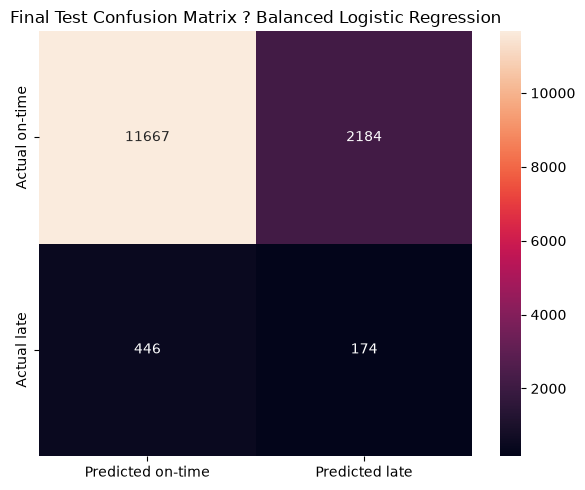

In [10]:
cm = confusion_matrix(
    y_test,
    test_prediction,
)

confusion = pd.DataFrame(
    cm,
    index=[
        "Actual on-time",
        "Actual late",
    ],
    columns=[
        "Predicted on-time",
        "Predicted late",
    ],
)

display(confusion)

tn, fp, fn, tp = cm.ravel()

print(f"True negatives: {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives: {tp:,}")

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
)

plt.title(
    "Final Test Confusion Matrix ? "
    "Balanced Logistic Regression"
)

plt.tight_layout()
plt.show()

## 11. Validation versus test comparison

A difference between validation and test performance is expected because the split is chronological and business conditions can change over time.

The comparison is diagnostic only.

The test result is **not** used to change the model.


In [11]:
performance_comparison = pd.DataFrame(
    [
        {
            "dataset": "validation",
            "pr_auc": NOTEBOOK_5_VALIDATION_PR_AUC,
            "roc_auc": NOTEBOOK_5_VALIDATION_ROC_AUC,
        },
        {
            "dataset": "test",
            "pr_auc": test_pr_auc,
            "roc_auc": test_roc_auc,
        },
    ]
)

display(
    performance_comparison.style.format(
        {
            "pr_auc": "{:.4f}",
            "roc_auc": "{:.4f}",
        }
    )
)

print(
    "PR-AUC change from validation to test: "
    f"{test_pr_auc - NOTEBOOK_5_VALIDATION_PR_AUC:+.6f}"
)

print(
    "ROC-AUC change from validation to test: "
    f"{test_roc_auc - NOTEBOOK_5_VALIDATION_ROC_AUC:+.6f}"
)

print("Model changed after test evaluation: NO")

,dataset,pr_auc,roc_auc
0,validation,0.1333,0.7743
1,test,0.0840,0.6783


PR-AUC change from validation to test: -0.049272
ROC-AUC change from validation to test: -0.095941
Model changed after test evaluation: NO


## 12. Final evaluation contract

Notebook 6 completes the offline model-development cycle.

The final model:

- uses the feature contract selected before test evaluation;
- uses the selected balanced logistic regression;
- uses the validation-selected threshold of `0.708020`;
- is fitted on train + validation;
- is evaluated exactly once on the chronological test split;
- does not use test results for tuning.

The next MLOps stage can package this frozen modelling logic into reproducible training/inference code and model artifacts.


In [12]:
print("NOTEBOOK 6 FINAL RESULT")
print(f"Development rows: {len(X_development):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Test late orders: {int(y_test.sum()):,}")
print(f"Test late rate: {y_test.mean():.4%}")
print(f"Final model: {SELECTED_MODEL_NAME}")
print(f"Frozen threshold: {SELECTED_THRESHOLD:.6f}")
print(f"Test accuracy: {test_accuracy:.6f}")
print(f"Test precision: {test_precision:.6f}")
print(f"Test recall: {test_recall:.6f}")
print(f"Test F1: {test_f1:.6f}")
print(f"Test PR-AUC: {test_pr_auc:.6f}")
print(f"Test ROC-AUC: {test_roc_auc:.6f}")
print(f"No-skill PR-AUC: {no_skill_pr_auc:.6f}")
print(f"PR-AUC lift: {pr_auc_lift:.2f}x")
print(f"True positives: {tp:,}")
print(f"False negatives: {fn:,}")
print(f"False positives: {fp:,}")
print(f"True negatives: {tn:,}")
print("Forbidden feature overlap: 0")
print("Threshold tuned on test: NO")
print("Model changed after test evaluation: NO")
print("Final test evaluation complete: YES")

NOTEBOOK 6 FINAL RESULT
Development rows: 81,999
Test rows: 14,471
Test late orders: 620
Test late rate: 4.2844%
Final model: logistic_balanced
Frozen threshold: 0.708020
Test accuracy: 0.818257
Test precision: 0.073791
Test recall: 0.280645
Test F1: 0.116857
Test PR-AUC: 0.083988
Test ROC-AUC: 0.678339
No-skill PR-AUC: 0.042844
PR-AUC lift: 1.96x
True positives: 174
False negatives: 446
False positives: 2,184
True negatives: 11,667
Forbidden feature overlap: 0
Threshold tuned on test: NO
Model changed after test evaluation: NO
Final test evaluation complete: YES
